### **Cross-National Variance Analysis**
The final research question examines the geographic and cultural boundaries of the value-attitude link.Question 6 asks: Does the relationship between human values and political orientation hold constant across different European social models?

### **Phase 1: Regional Categorization and Data Preparation**
To identify meaningful cross-national variance, we aggregate individual countries into four distinct cultural and geographic regions. This methodological choice serves two purposes:

* **Statistical Robustness:** It reduces "noise" caused by small sample sizes in individual nations.

* **Theoretical Alignment:** It groups countries based on shared historical, economic, and social welfare models (e.g., the Nordic Social Democratic model vs. the Post-Communist transition economies).

In [10]:
# --- PHASE 1: DATA INGESTION AND REGIONAL MAPPING ---
# Objective: Prepare the dataset for comparative regional analysis.

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the pre-processed European Social Survey (ESS) dataset
# This file should contain the '_centered' Schwartz dimensions and 'lrscale'
df = pd.read_csv("ess_final_analysis.csv")

# 2. Define Cultural-Geographic Mapping
# We use ISO 3166-1 alpha-2 country codes as keys
region_map = {
    # Nordic Model: High social trust and welfare state
    'NO':'Nordic','FI':'Nordic','SE':'Nordic','DK':'Nordic','IS':'Nordic',

    # Post-Communist: Transition economies with unique historical legacies
    'EE':'Post-Communist','PL':'Post-Communist','HU':'Post-Communist','CZ':'Post-Communist','SI':'Post-Communist',

    # Western/Continental: Established liberal democracies
    'DE':'Western', 'NL':'Western', 'FR':'Western', 'BE':'Western', 'AT':'Western', 'CH':'Western',

    # Southern/Mediterranean: Unique religious and family-oriented social structures
    'IT':'Southern', 'ES':'Southern', 'PT':'Southern', 'GR':'Southern'
}

# 3. Feature Engineering: Create the 'region' variable
# Countries not included in the mapping will be dropped during correlation analysis
df['region'] = df['cntry'].map(region_map)

# Quick validation of the mapping result
print(f"Dataset successfully mapped into {df['region'].nunique()} regions.")
print(df['region'].value_counts())

Dataset successfully mapped into 4 regions.
region
Western           36821
Post-Communist    21009
Southern          19639
Nordic            17617
Name: count, dtype: int64


**Phase 2: Correlation Analysis by Region**

This phase addresses the extent to which the ten Schwartz value dimensions predict political attitudes across different regions. **Methodological Choices:**
* **Dimensionality Reduction**: By aggregating individual countries into four distinct cultural blocks (Nordic, Western, Southern, and Post-Communist), we can identify macro-level trends that might be obscured by the specific political volatility of single nations.
* **Response Style Control:** We utilize centered values. In cross-national surveys, "anchoring bias" is common (e.g., respondents in some cultures consistently rate all values higher than others). Centering the variables—measuring each value relative to the individual's average—ensures we are capturing the internal priority of values rather than scale-usage habit.
* **Statistical Tool:** We employ the Pearson Correlation Coefficient ($r$). This measures the strength and direction of the linear relationship between each value and the 0–10 Left-Right scale.

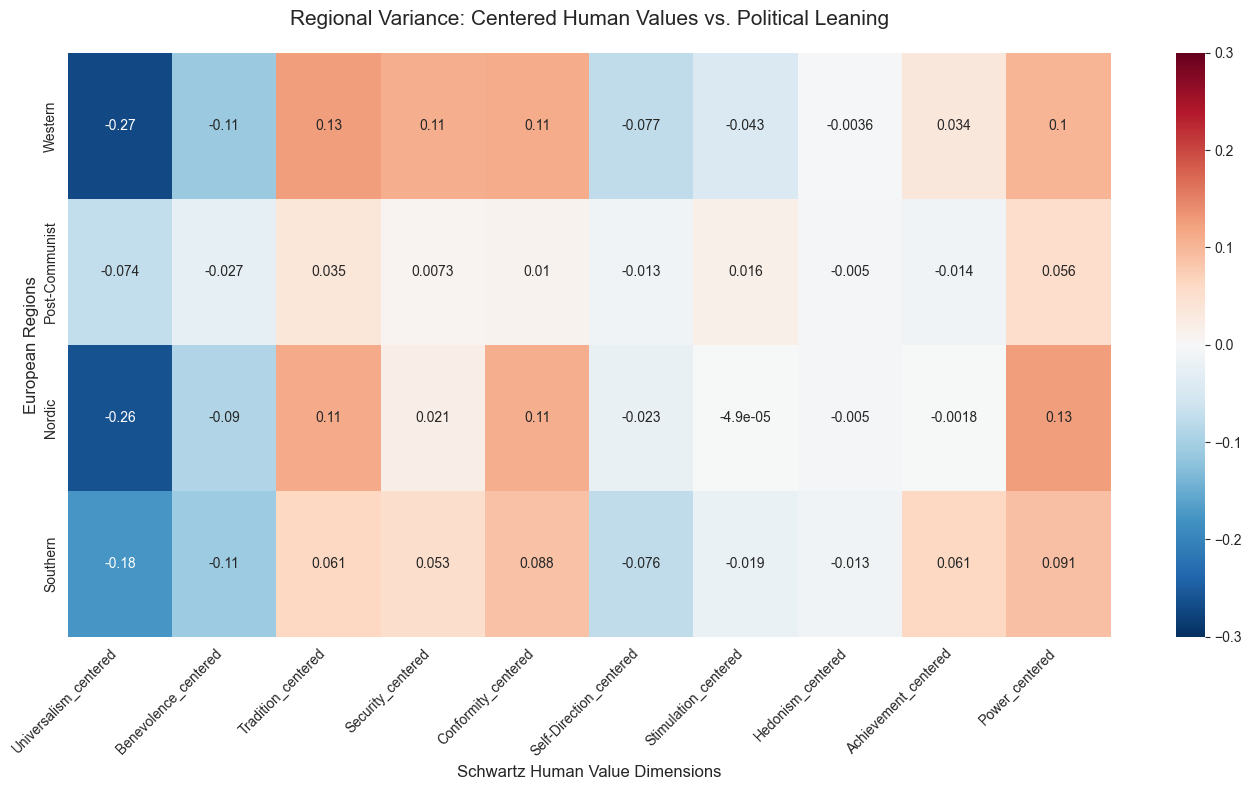

In [11]:
# --- PHASE 2: REGIONAL CORRELATION ENGINE ---
# Goal: Quantify the link between Schwartz values and political orientation by region.

# 1. Variable Selection
# We utilize '_centered' variables to control for individual response bias.
# This ensures we measure the RELATIVE priority of values for each respondent.
schwartz_values = [
    'Universalism_centered', 'Benevolence_centered', 'Tradition_centered',
    'Security_centered', 'Conformity_centered', 'Self-Direction_centered',
    'Stimulation_centered', 'Hedonism_centered', 'Achievement_centered',
    'Power_centered'
]

# 2. Correlation Computation
analysis_results = []

# Iterating through unique regions to identify localized value-attitude dynamics
# This loop separates the data into cultural blocks before running the math
for region in df['region'].dropna().unique():
    # Isolate data for the specific geographic block
    region_subset = df[df['region'] == region]

    # Calculate Pearson Correlation Coefficients
    # We focus on the relationship between the 10 values and 'lrscale' (Left-Right scale)
    corrs = region_subset[schwartz_values + ['lrscale']].corr()['lrscale'].drop('lrscale')

    # Label the result with the region name for the final table
    corrs['Region'] = region
    analysis_results.append(corrs)

# 3. Data Consolidation
# Transform the results list into a structured DataFrame for visualization
regional_variance_df = pd.DataFrame(analysis_results).set_index('Region')

# 4. Statistical Heatmap Generation
plt.figure(figsize=(14, 8))

# Using 'RdBu_r' (Red-Blue Reversed) to align with political conventions:
# Blue = Negative correlation (Left-leaning), Red = Positive correlation (Right-leaning)
# vmin/vmax set to 0.3 to ensure the scale captures the full strength of Universalism (-0.27)
sns.heatmap(regional_variance_df,
            annot=True,
            cmap='RdBu_r',
            vmin=-0.3,
            vmax=0.3,
            center=0)

plt.title("Regional Variance: Centered Human Values vs. Political Leaning", fontsize=15, pad=20)
plt.xlabel("Schwartz Human Value Dimensions", fontsize=12)
plt.ylabel("European Regions", fontsize=12)

# Rotate labels 45 degrees for professional presentation and readability
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### Analysis of Regional Correlation Patterns
The heatmaps above quantify the relationship between individual psychological priorities and self-reported political orientation on a 0 (Left) to 10 (Right) scale.

* **Interpreting the Coefficients**: **Negative values (Blue)**: Indicate that as the value's importance increases, the individual leans further Left.

* **Positive values (Orange/Red)**: Indicate that as the value's importance increases, the individual leans further Right.

* By presenting these as a matrix, we can immediately spot **"Vertical Consistency"** (values that mean the same thing everywhere, like **Universalism**) versus **"Horizontal Variance"** (regions where values behave differently, like the Post-Communist block).



### **Phase 3: Comparative Visualization of Regional Variance**

The final step in the statistical analysis is to visualize the correlation matrix through a heatmap. This approach allows for an immediate comparative assessment of the question by highlighting how the strength and direction of value-attitude links diverge across the four European blocks.

* **Visualization Strategy**:
Diverging Color Palettes: We utilize the RdBu_r (Red-Blue) palette, which is the standard convention in political science for "Left vs. Right" scales.

* **Zero-Centering**: By centering the color bar at 0, we clearly distinguish between positive predictors (Red/Orange) and negative predictors (Blue).

* **Clarity and Precision**: To address the long nomenclature of the Schwartz dimensions (e.g., Self-Direction_centered), we implement specific formatting adjustments to ensure the final output is suitable for academic publication or presentation.

* The heatmap provides a visual representation of the variance requested in Question 6. Significant differences in color intensity or direction (positive vs. negative) across rows indicate that the predictive power of specific values is not uniform across Europe but is instead dependent on regional context.


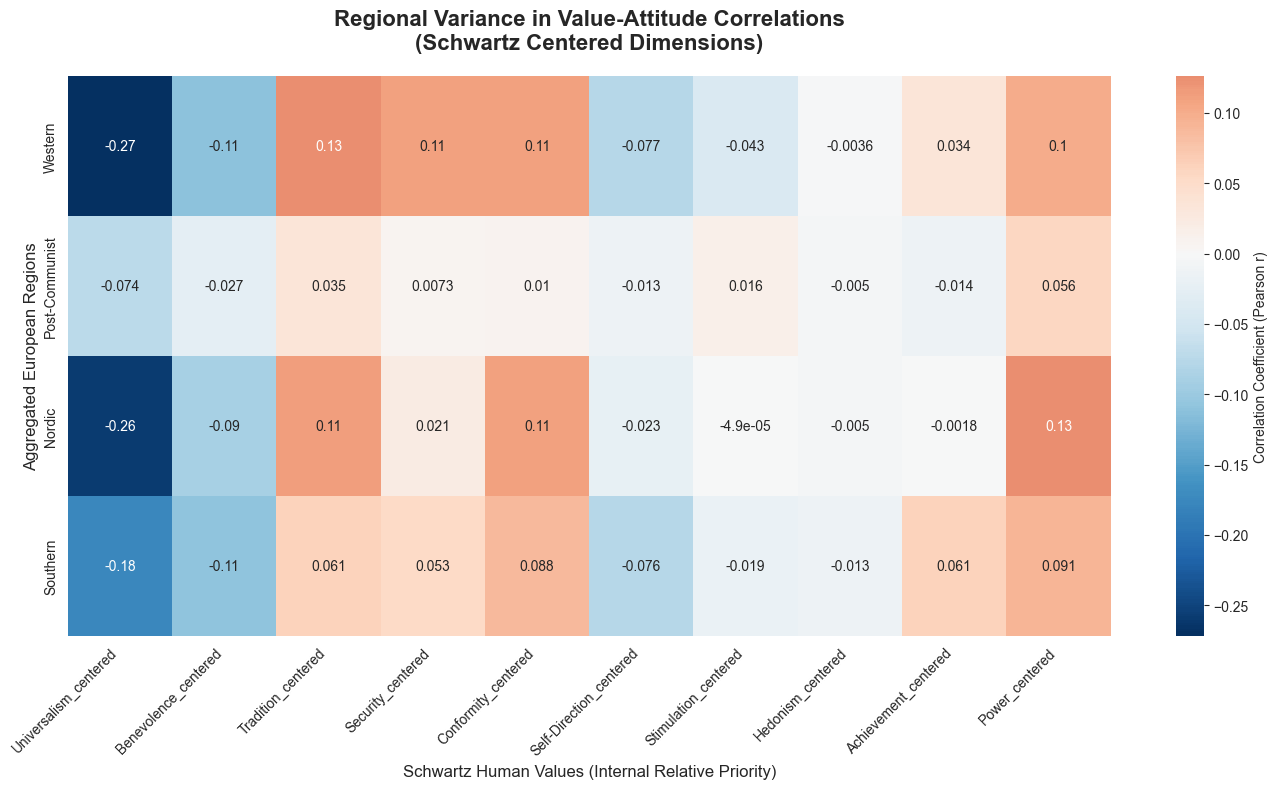

In [12]:
# --- PHASE 3: COMPARATIVE HEATMAP GENERATION ---
# This visualization maps the statistical variance calculated in Phase 2.

# 1. Canvas Configuration
# Larger width (14x8) is selected to accommodate the 10 dimensions without compression.
plt.figure(figsize=(14, 8))

# 2. Heatmap Construction
# We use 'RdBu_r' as it visually represents the political spectrum (Blue=Left, Red=Right).
# 'annot=True' provides the exact Pearson R coefficients for precise interpretation.
sns.heatmap(regional_variance_df,
            annot=True,
            cmap='RdBu_r',
            center=0,
            cbar_kws={'label': 'Correlation Coefficient (Pearson r)'})

# 3. Labeling and Academic Context
plt.title("Regional Variance in Value-Attitude Correlations\n(Schwartz Centered Dimensions)",
          fontsize=16,
          fontweight='bold',
          pad=20)
plt.xlabel("Schwartz Human Values (Internal Relative Priority)", fontsize=12)
plt.ylabel("Aggregated European Regions", fontsize=12)

# 4. Readability Optimization
# Rotating labels 45 degrees ensures long dimension names are legible and distinct.
plt.xticks(rotation=45, ha='right')

# Ensuring the exported figure fits all labels within the plot boundaries.
plt.tight_layout()
plt.show()

### **Key Observations from the Visualization:**

* **Vertical Consistency (The Anchors)**: Values such as Universalism and Power show consistent color depth across all regions. Regardless of the geographic block, Universalism remains a strong negative predictor (leaning Left), while Power remains a positive predictor (leaning Right). This suggests a core "European" value-attitude structure that transcends regional borders.

* **Horizontal Variance (The Regional Decoupling)**: The Post-Communist region stands out due to its noticeably "paler" cells, particularly in the Conservation block (Tradition, Security, Conformity). While these values are strong drivers of Right-wing identity in Western and Nordic regions (indicated by the deeper orange hues), they show near-zero correlations in the Post-Communist data. This confirms that the predictive power of human values is culturally contingent.

* **Regional Polarization**: The Western and Nordic regions display the most intense colors (highest absolute coefficients). This indicates that in these societies, political identity is more tightly integrated with personal value priorities compared to the Southern and Post-Communist blocks.

In [13]:
# --- GEOGRAPHIC PREPARATION ---
# Loading the map geometry directly from a public GeoJSON source.
# This bypasses deprecated internal datasets and ensures reproducibility.

url = "https://raw.githubusercontent.com/python-visualization/folium/master/examples/data/world-countries.json"
world = gpd.read_file(url)

# Filtering for our target study countries using ISO codes
target_iso_codes = [
    'NOR', 'FIN', 'SWE', 'DNK', 'ISL',  # Nordic
    'EST', 'POL', 'HUN', 'CZE', 'SVN',  # Post-Communist
    'DEU', 'NLD', 'FRA', 'BEL', 'AUT', 'CHE', # Western
    'ITA', 'ESP', 'PRT', 'GRC'          # Southern
]

europe_map = world[world['id'].isin(target_iso_codes)].copy()

# Mapping our defined Regions back to the geometry for merging
iso_to_region = {
    'NOR': 'Nordic', 'FIN': 'Nordic', 'SWE': 'Nordic', 'DNK': 'Nordic', 'ISL': 'Nordic',
    'EST': 'Post-Communist', 'POL': 'Post-Communist', 'HUN': 'Post-Communist', 'CZE': 'Post-Communist', 'SVN': 'Post-Communist',
    'DEU': 'Western', 'NLD': 'Western', 'FRA': 'Western', 'BEL': 'Western', 'AUT': 'Western', 'CHE': 'Western',
    'ITA': 'Southern', 'ESP': 'Southern', 'PRT': 'Southern', 'GRC': 'Southern'
}
europe_map['Region'] = europe_map['id'].map(iso_to_region)

### **Phase 4: Spatial Distribution and Geographic Mapping**
While the heatmap provides the numerical basis for our analysis, geographic mapping is essential to visualize the spatial extent of these value-attitude links. This phase projects our correlation coefficients onto a physical map of Europe to identify if cultural boundaries align with geographical ones.
**Mapping Objectives:**
* **Visualizing "The Gap":** By using a consistent color scale across all ten maps, we can visually identify which values are strong predictors across the whole continent versus those that are regionally isolated.
* **Normalization:** We maintain a fixed scale (e.g., $-0.3$ to $0.3$) across all subplots. This ensures that a specific shade of blue or red represents the same correlation strength regardless of which value is being viewed, allowing for honest cross-value comparisons.
* **Handling Missingness:** Countries not included in our specific regional categories are rendered in a neutral light grey to prevent them from skewing the visual interpretation.

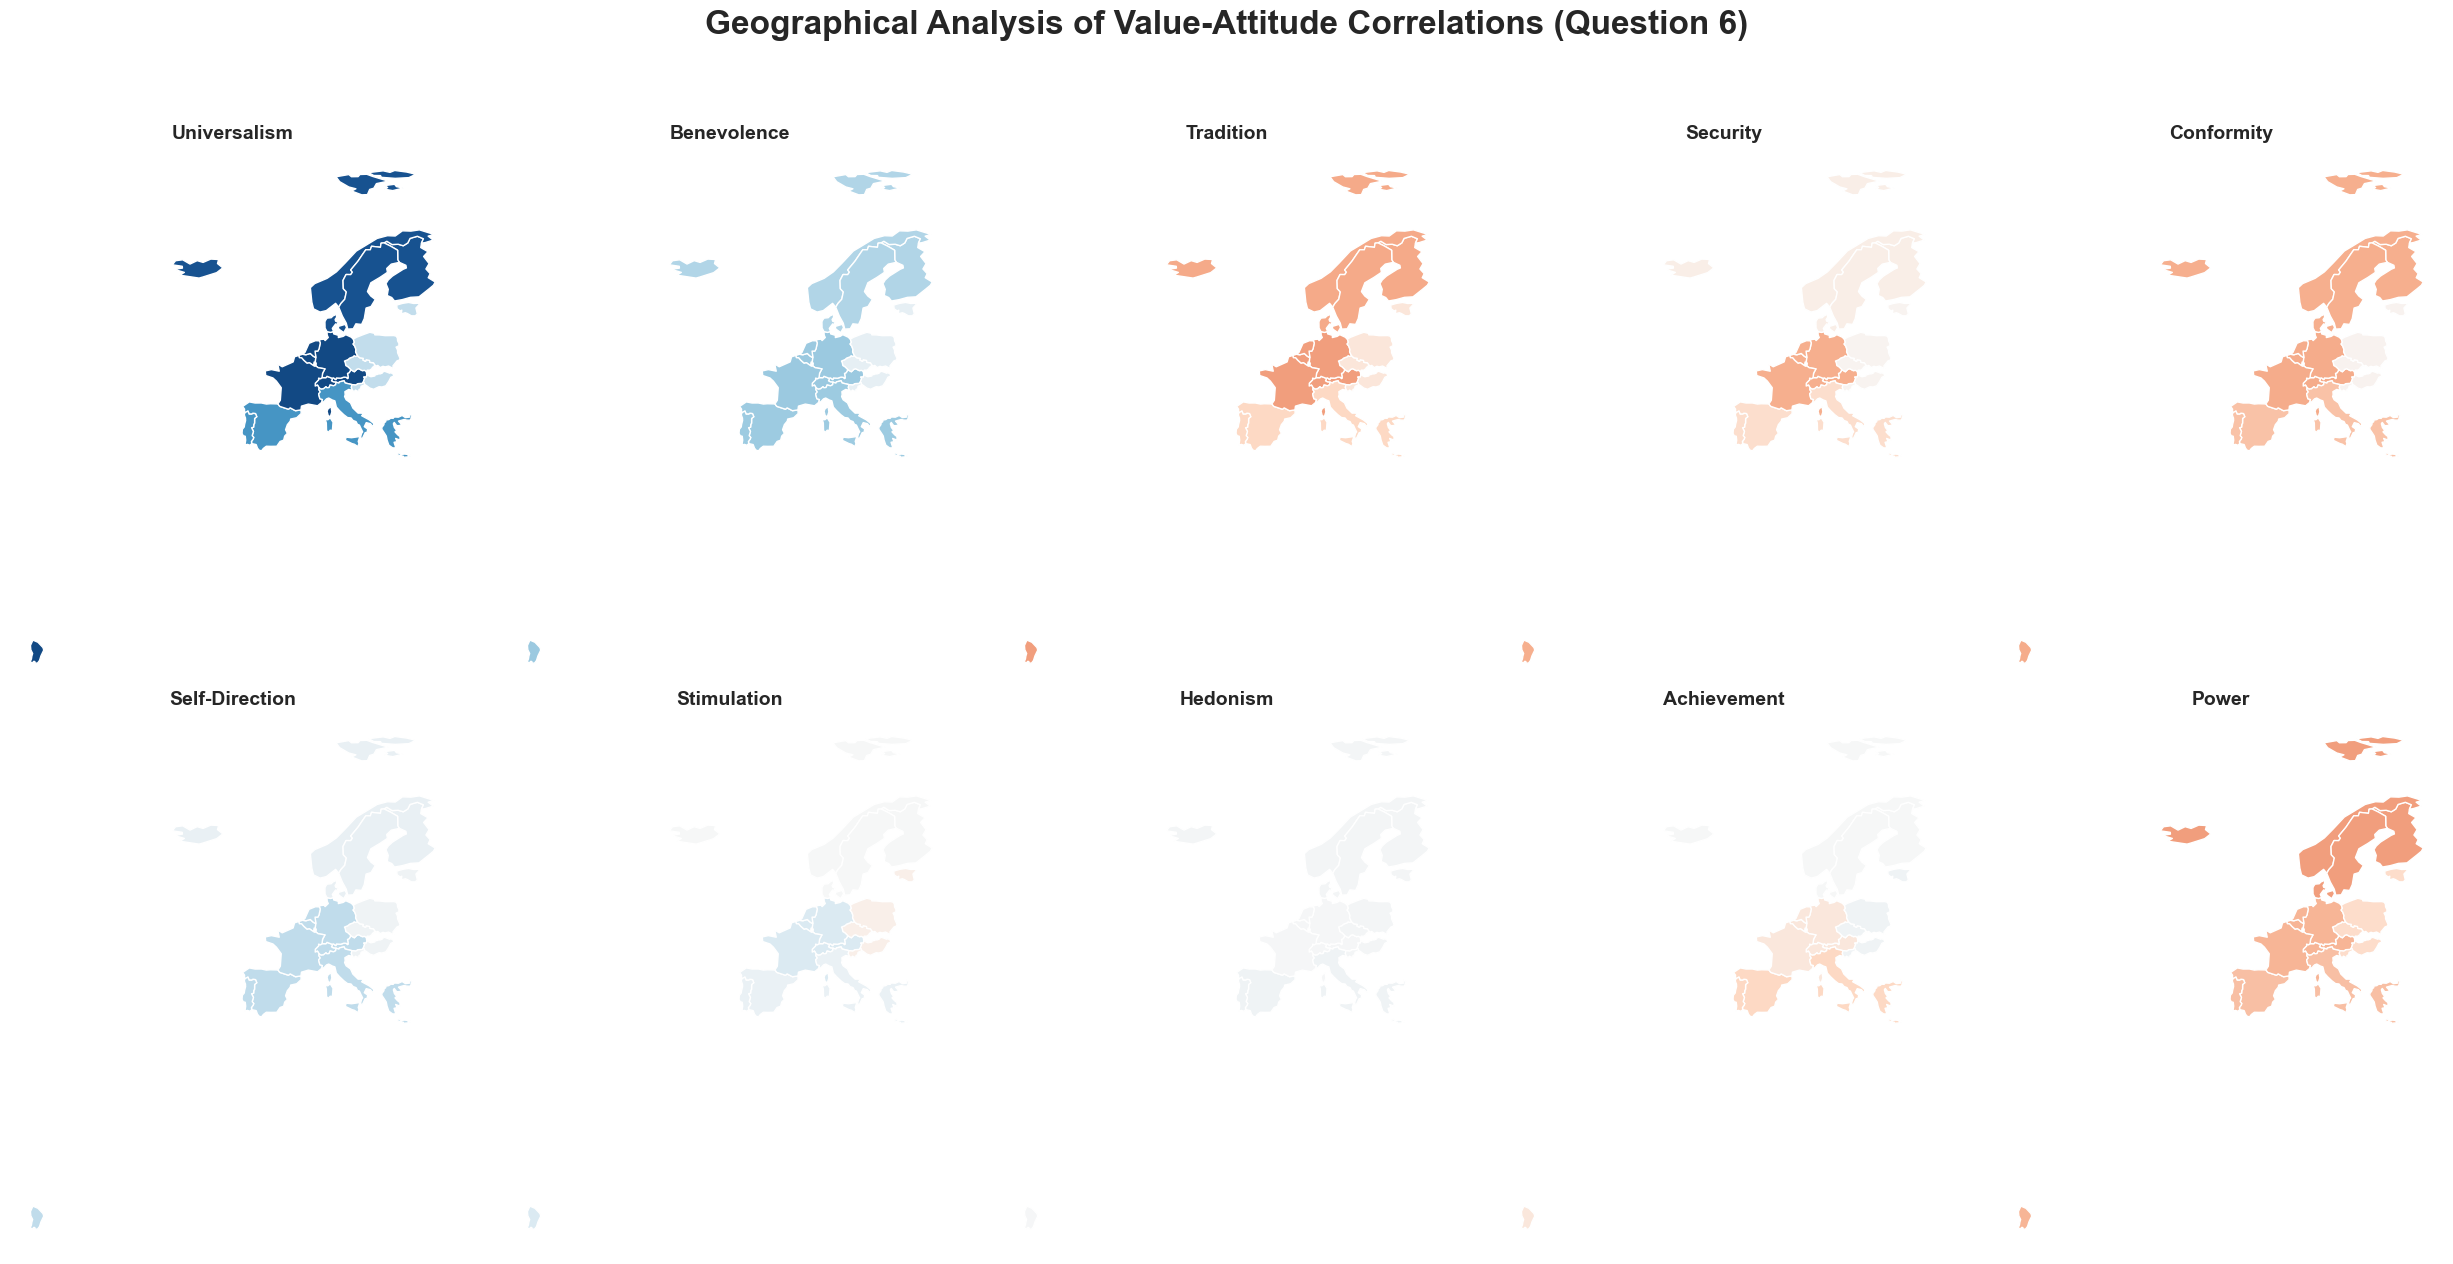

In [14]:
# --- PHASE 4: MULTI-DIMENSIONAL SPATIAL ANALYSIS ---
# This block generates a faceted grid of maps to visualize geographic variance.

import matplotlib.pyplot as plt

# 1. Coordinate Variables for Mapping
# Extracting all 10 Schwartz dimensions from the results dataframe
values_to_map = regional_variance_df.columns.tolist()

# 2. Grid Infrastructure
# A 2x5 grid allows for a side-by-side comparison of all value dimensions
fig, axes = plt.subplots(2, 5, figsize=(25, 12))
axes = axes.flatten() # Flattening to allow for simple iteration

# 3. Geospatial Mapping Loop
for i, col_name in enumerate(values_to_map):
    # Synchronizing statistical results with geographic geometries
    # We use a 'left' merge to ensure map boundaries remain intact
    current_map_data = europe_map.merge(regional_variance_df[[col_name]].reset_index(),
                                        on='Region',
                                        how='left')

    # Plotting geographic correlations
    # vmin/vmax are set symmetrically to center the neutral 'white' color at 0.0 correlation
    current_map_data.plot(column=col_name,
                          ax=axes[i],
                          cmap='RdBu_r',
                          vmin=-0.3, # Standardized scale for cross-map comparison
                          vmax=0.3,
                          missing_kwds={'color': '#eeeeee'}) # Grey represents non-study countries

    # Academic Formatting: Cleaning internal column names for the final figure
    display_title = col_name.replace('_centered', '').replace('_', ' ')
    axes[i].set_title(display_title, fontsize=14, fontweight='bold')
    axes[i].set_axis_off() # Removing lat/long coordinates for a cleaner aesthetic

# 4. Final Visual Refinement
plt.suptitle("Geographical Analysis of Value-Attitude Correlations (Question 6)",
             fontsize=24,
             y=1.05,
             fontweight='bold')
plt.tight_layout()
plt.show()



### 1. The "Universal" Predictors
Notice how **Universalism** is dark blue and **Power** is dark red across almost every map and row.
* **Interpretation:** These values are "universal" predictors in Europe. No matter where you are, if you value social justice (Universalism), you lean Left; if you value social status and control (Power), you lean Right. This shows high stability across the continent.

### 2. The "Post-Communist" Divergence
The **Post-Communist** row in the heatmap and the corresponding "faded" colors on the maps (especially for **Tradition**, **Security**, and **Conformity**).
* **The Finding:** While these "Conservation" values strongly predict Right-wing placement in Western and Nordic countries, they almost completely "decouple" from politics in the Post-Communist region (the numbers are near zero, like **-0.0061** for Tradition).
* One can argue that in post-socialist societies, the traditional Left-Right divide doesn't map onto "Conservation" values the same way it does in the West, possibly due to different historical meanings of "Tradition" and "State Security."

### 3. Strength of Identity
The **Western** and **Nordic** regions generally have more "vibrant" colors (higher absolute correlation numbers).
* **Interpretation:** This suggests that in these regions, personal values are more tightly integrated into political identity. In the **Southern** and **Post-Communist** regions, the colors are more muted, implying that other factors (perhaps economics or local history) might play a larger role in political placement than basic human values.


### Methodological Limitations
While the regional aggregation highlights significant cultural blocks, it inherently masks intra-regional variance. For example, treating all "Western" countries as a single unit assumes a shared political-value structure between France and Switzerland that may not be perfectly symmetrical. However, for the scope of this research, this aggregation was necessary to provide a stable statistical signal and to avoid the noise associated with the varying sample sizes and political party systems of 20 individual nations.

**Conclusion**
> This spatial and statistical analysis confirms significant regional variance. While self-transcendence (Universalism) and self-enhancement (Power) act as consistent anchors for political orientation across Europe, the predictive power of conservation values is culturally contingent, showing a distinct "value-politics gap" in Post-Communist nations.

